## 1. Importaciones y Configuración

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy import optimize
from scipy.integrate import simpson
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Configuración de gráficos
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Constantes (unidades atómicas: hbar = m = 1)
hbar = 1.0
m = 1.0

## 2. Parámetros del Pozo Finito

Parámetros del pozo finito:
  Semi-ancho: a = 0.5000
  Profundidad: V0 = 400.0000
  Rango espacial: [-15.00, 15.00]
  Grid: 3000 puntos, h = 0.010003


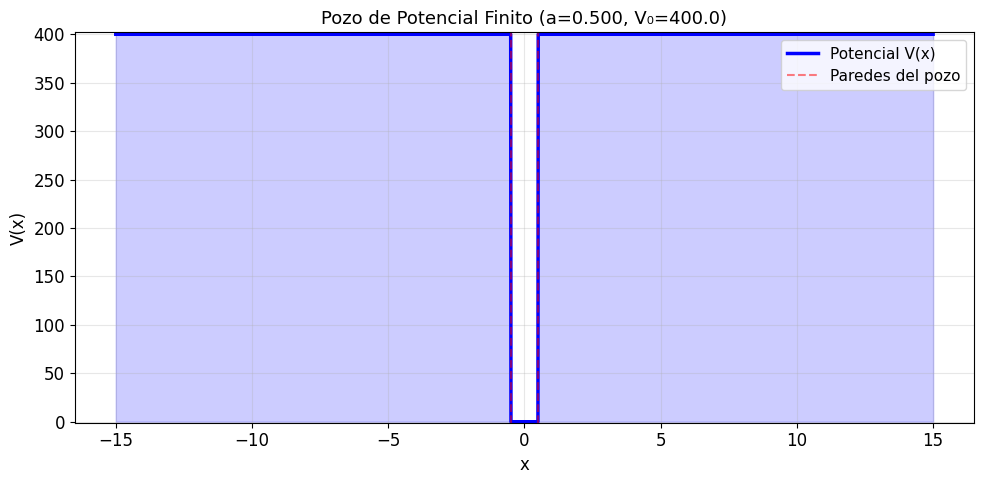

In [78]:
# Parámetros del pozo finito (configurables)
a = 0.5      # Semi-ancho del pozo
V0 = 400          # Profundidad del pozo

# Parámetros de grid (adaptativos basados en a y V0)
x_range = max(4 * a, 15.0)
N_points = 3000
x = np.linspace(-x_range, x_range, N_points)
h = x[1] - x[0]

# Crear potencial
V = np.where(np.abs(x) < a, 0, V0)

print(f"Parámetros del pozo finito:")
print(f"  Semi-ancho: a = {a:.4f}")
print(f"  Profundidad: V0 = {V0:.4f}")
print(f"  Rango espacial: [{-x_range:.2f}, {x_range:.2f}]")
print(f"  Grid: {N_points} puntos, h = {h:.6f}")

# Visualizar el potencial
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, V, 'b-', linewidth=2.5, label='Potencial V(x)')
ax.axvline(x=-a, color='r', linestyle='--', alpha=0.5, label='Paredes del pozo')
ax.axvline(x=a, color='r', linestyle='--', alpha=0.5)
ax.fill_between(x, 0, V, alpha=0.2, color='blue')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('V(x)', fontsize=12)
ax.set_title(f'Pozo de Potencial Finito (a={a:.3f}, V₀={V0:.1f})', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, V0 + 2)
plt.tight_layout()
plt.show()

## 3. Método de Numerov y Búsqueda de Autovalores

In [79]:
def solve_schrodinger(x, V, E, hbar=1.0, m=1.0):
    """
    Resuelve la ecuación de Schrödinger usando shooting bilateral con método de Numerov.
    Retorna: (psi, psi_left, psi_right, n_match)
    """
    n = len(x)
    h = x[1] - x[0]
    n_match = n // 2
    
    # Calcular coeficientes de Numerov
    g = 2.0 * m * (E - V) / hbar**2
    c0 = 1.0 + h**2 * g / 12.0
    c1 = 2.0 * (1.0 - 5.0 * h**2 * g / 12.0)
    
    # Integración desde la izquierda
    psi_left = np.zeros(n)
    psi_left[0] = 0.0
    psi_left[1] = 1e-10
    
    for i in range(1, n_match):
        psi_left[i+1] = (c1[i] * psi_left[i] - c0[i-1] * psi_left[i-1]) / c0[i+1]
    
    # Integración desde la derecha
    psi_right = np.zeros(n)
    psi_right[-1] = 0.0
    psi_right[-2] = 1e-10
    
    for i in range(n-2, n_match, -1):
        psi_right[i-1] = (c1[i] * psi_right[i] - c0[i+1] * psi_right[i+1]) / c0[i-1]
    
    # Matching
    psi_L_match = psi_left[n_match]
    psi_R_match = psi_right[n_match]
    
    if abs(psi_L_match) < 1e-15 or abs(psi_R_match) < 1e-15:
        return np.zeros(n), psi_left, psi_right, n_match
    
    # Amplitudes
    amp_L = np.max(np.abs(psi_left[1:n_match+1]))
    amp_R = np.max(np.abs(psi_right[n_match:-1]))
    
    if min(amp_L, amp_R) > 1e-15:
        ratio = max(amp_L, amp_R) / min(amp_L, amp_R)
        if ratio > 1e6:
            return np.zeros(n), psi_left, psi_right, n_match
    
    if amp_L < 1e-12 or amp_R < 1e-12:
        return np.zeros(n), psi_left, psi_right, n_match
    
    # Normalizar antes de scaling
    scale_L = 1.0 / amp_L if amp_L > 1e-15 else 1.0
    scale_R = 1.0 / amp_R if amp_R > 1e-15 else 1.0
    
    psi_left_norm = psi_left * scale_L
    psi_right_norm = psi_right * scale_R
    
    scale_factor = psi_left_norm[n_match] / psi_right_norm[n_match]
    psi_right_scaled = psi_right_norm * scale_factor
    
    psi = np.concatenate([psi_left_norm[:n_match+1], psi_right_scaled[n_match+1:]])
    
    return psi, psi_left_norm, psi_right_scaled, n_match


def boundary_condition(E, x, V, hbar=1.0, m=1.0):
    """
    Condición de frontera para encontrar autovalores.
    """
    psi, psi_left, psi_right, n_match = solve_schrodinger(x, V, E, hbar, m)
    h = x[1] - x[0]
    n = len(x)
    
    if np.max(np.abs(psi)) < 1e-14:
        return 1.0
    
    psi_c = psi[n_match]
    if abs(psi_c) < 1e-14:
        return 1.0
    
    amp_L = np.max(np.abs(psi_left[1:n_match+1]))
    amp_R = np.max(np.abs(psi_right[n_match:-1]))
    
    if amp_L < 1e-12 and amp_R < 1e-12:
        return 1.0
    
    if min(amp_L, amp_R) > 1e-15:
        ratio = max(amp_L, amp_R) / min(amp_L, amp_R)
        if ratio > 1e5:
            return 1.0
    
    if n_match > 1 and n_match < n - 2:
        dpsi_c = (psi[n_match+1] - psi[n_match-1]) / (2.0 * h)
    else:
        dpsi_c = 0.0
    
    log_deriv = dpsi_c / psi_c if abs(psi_c) > 1e-15 else 0.0
    
    if n_match > 0 and abs(psi_left[n_match]) > 1e-15:
        dpsi_L = (psi_left[n_match] - psi_left[n_match-1]) / h
        log_deriv_L = dpsi_L / psi_left[n_match]
    else:
        log_deriv_L = 0.0
    
    if n_match < n - 1 and abs(psi_right[n_match]) > 1e-15:
        dpsi_R = (psi_right[n_match+1] - psi_right[n_match]) / h
        log_deriv_R = dpsi_R / psi_right[n_match]
    else:
        log_deriv_R = 0.0
    
    discontinuity = log_deriv_L - log_deriv_R
    if abs(discontinuity) > 1e10:
        return 1.0
    
    return discontinuity


def find_eigenvalues(x, V, E_min, E_max, n_search=2000, hbar=1.0, m=1.0, tol=1e-3):
    """
    Encuentra autovalores usando shooting bilateral.
    """
    E_test = np.linspace(E_min, E_max, n_search)
    bc_values = np.array([boundary_condition(E, x, V, hbar, m) for E in E_test])
    
    eigenvalues = []
    for i in range(len(bc_values) - 1):
        if bc_values[i] * bc_values[i+1] < 0:
            try:
                E_eigen = optimize.brentq(boundary_condition, E_test[i], E_test[i+1], 
                                         args=(x, V, hbar, m))
                
                _, psi_L, psi_R, n_match = solve_schrodinger(x, V, E_eigen, hbar, m)
                amp_L = np.max(np.abs(psi_L[1:n_match+1]))
                amp_R = np.max(np.abs(psi_R[n_match:-1]))
                
                if min(amp_L, amp_R) > 1e-15:
                    ratio = max(amp_L, amp_R) / min(amp_L, amp_R)
                    if ratio > 1e5:
                        continue
                
                if amp_L < 1e-12 or amp_R < 1e-12:
                    continue
                
                is_duplicate = False
                for E_prev in eigenvalues:
                    if abs(E_eigen - E_prev) < tol:
                        is_duplicate = True
                        break
                
                if not is_duplicate:
                    eigenvalues.append(E_eigen)
            except:
                pass
    
    return np.array(eigenvalues), E_test, bc_values

## 4. Búsqueda de Autovalores y Autofunciones

In [80]:
# Buscar autovalores
print("Buscando autovalores de energía...")
E_min = 0.01
E_max = V0 - 0.01

eigenvalues, E_test, bc_values = find_eigenvalues(
    x, V, E_min, E_max,
    n_search=3000,
    hbar=hbar,
    m=m,
    tol=0.05
)

print(f"\n✓ Autovalores encontrados: {len(eigenvalues)}")
print(f"\nPrimeros 8 autovalores:")
for i, E in enumerate(eigenvalues[:8]):
    print(f"  E_{i} = {E:.8f}")

# Calcular autofunciones normalizadas
def normalize_wavefunction(x, psi):
    norm = simpson(np.abs(psi)**2, x=x)
    return psi / np.sqrt(norm)

print("\nCalculando autofunciones...")
eigenfunctions = []
probability_densities = []

for i, E in enumerate(eigenvalues):
    psi, _, _, _ = solve_schrodinger(x, V, E, hbar, m)
    psi_norm = normalize_wavefunction(x, psi)
    eigenfunctions.append(psi_norm)
    probability_densities.append(np.abs(psi_norm)**2)
    if (i+1) % 5 == 0:
        print(f"  {i+1}/{len(eigenvalues)} estados procesados...")

eigenfunctions = np.array(eigenfunctions)
probability_densities = np.array(probability_densities)
print(f"\n✓ {len(eigenfunctions)} autofunciones calculadas y normalizadas")

Buscando autovalores de energía...

✓ Autovalores encontrados: 10

Primeros 8 autovalores:
  E_0 = 4.37839576
  E_1 = 17.17634145
  E_2 = 39.32549365
  E_3 = 68.49835724
  E_4 = 108.73527635
  E_5 = 153.19445244
  E_6 = 211.23345215
  E_7 = 269.07967394

Calculando autofunciones...
  5/10 estados procesados...
  10/10 estados procesados...

✓ 10 autofunciones calculadas y normalizadas


## 5. Función de Termalización para 1 Partícula

In [81]:
def P_thermal_single_finite(x_pos, T, eigenvalues, eigenfunctions):
    """
    Densidad térmica para 1 partícula en pozo finito.
    
    P_th(x,T) = sum_i exp(-E_i/T) |psi_i(x)|^2 / Z
    
    Parámetros:
    -----------
    x_pos : float o array
        Posición(es) donde evaluar
    T : float
        Temperatura (en unidades de energía)
    eigenvalues : array
        Autovalores de energía
    eigenfunctions : array 2D
        Array de autofunciones normalizadas
    
    Retorna:
    --------
    P_th : array
        Densidad de probabilidad térmica
    """
    if np.isscalar(x_pos):
        x_pos = np.array([x_pos])
    
    P_th = np.zeros_like(x_pos, dtype=float)
    Z = 0.0
    
    for E, psi in zip(eigenvalues, eigenfunctions):
        # Weights
        w = np.exp(-E / T)
        Z += w
        
        # Interpolate psi at x_pos
        psi_at_x = np.interp(x_pos, x, psi)
        P_th += w * np.abs(psi_at_x)**2
    
    return P_th / Z

# Test
print("Test: Calculando P_th para algunas temperaturas...")
test_temps = [1, 5, 10]
for T in test_temps:
    x_test = 0.0
    P = P_thermal_single_finite(x_test, T, eigenvalues, eigenfunctions)
    print(f"  T = {T:3.1f}: P_th(0, T) = {P[0]:.6f}")

Test: Calculando P_th para algunas temperaturas...
  T = 1.0: P_th(0, T) = 1.848593
  T = 5.0: P_th(0, T) = 1.716001
  T = 10.0: P_th(0, T) = 1.453756


## 6. FIGURA 1a: Densidad Térmica para 1 Partícula

Calculando P_th(x,T) para múltiples temperaturas...


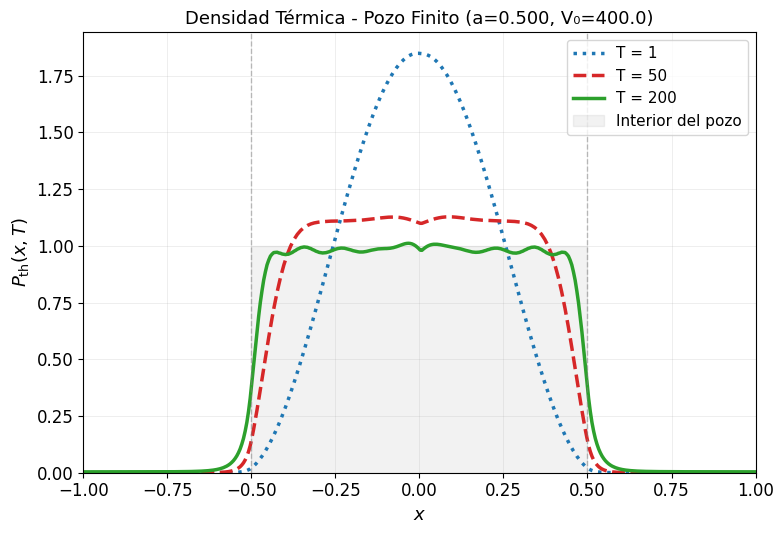

✓ Figura 1a guardada


In [90]:
# Calcular P_th para diferentes temperaturas
print("Calculando P_th(x,T) para múltiples temperaturas...")

x_plot = np.linspace(-a - 1, a + 1, 600)  # Solo región relevante
temperatures = [1, 50, 200]  # Temperatura adimensional

fig_1a, ax = plt.subplots(figsize=(8, 5.5))

for T, color, style, lw, label in [(1, 'C0', ':', 2.5, 'T = 1'),
                                     (50, 'C3', '--', 2.5, 'T = 50'),
                                     (200, 'C2', '-', 2.5, 'T = 200')]:
    P_th = np.array([P_thermal_single_finite(xi, T, eigenvalues, eigenfunctions) for xi in x_plot])
    ax.plot(x_plot, P_th, color=color, linestyle=style, linewidth=lw, label=label)

# Decoración
ax.axvline(x=-a, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=a, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.fill_between([-a, a], 0, 1, alpha=0.1, color='gray', label='Interior del pozo')

ax.set_xlabel('$x$', fontsize=13)
ax.set_ylabel('$P_{\\rm th}(x,T)$', fontsize=13)
ax.set_title(f'Densidad Térmica - Pozo Finito (a={a:.3f}, V₀={V0:.1f})', fontsize=13)
ax.legend(loc='upper right', fontsize=11, frameon=True)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_xlim(-a - 0.5, a + 0.5)
ax.set_ylim(0, ax.get_ylim()[1])

plt.tight_layout()
plt.savefig('figures/finite_well_fig1a_Pth.png', dpi=150)
plt.show()
print("✓ Figura 1a guardada")

## 8. Funciones para 2 Partículas

In [84]:
def P2_bosons_finite(i1, i2, x1, x2, eigenfunctions):
    """
    Probabilidad conjunta para bosones: 2 partículas en estados i1 e i2.
    P^b(x1,x2) = |psi_i1(x1)*psi_i2(x2) + psi_i1(x2)*psi_i2(x1)|^2
    """
    psi_i1 = np.interp(x1, x, eigenfunctions[i1])
    psi_i2 = np.interp(x2, x, eigenfunctions[i2])
    psi_i1_t = np.interp(x2, x, eigenfunctions[i1])
    psi_i2_t = np.interp(x1, x, eigenfunctions[i2])
    
    f = psi_i1 * psi_i2 + psi_i1_t * psi_i2_t
    return f**2


def P2_fermions_finite(i1, i2, x1, x2, eigenfunctions):
    """
    Probabilidad conjunta para fermiones: 2 partículas en estados i1 < i2.
    P^f(x1,x2) = |psi_i1(x1)*psi_i2(x2) - psi_i1(x2)*psi_i2(x1)|^2
    """
    psi_i1 = np.interp(x1, x, eigenfunctions[i1])
    psi_i2 = np.interp(x2, x, eigenfunctions[i2])
    psi_i1_t = np.interp(x2, x, eigenfunctions[i1])
    psi_i2_t = np.interp(x1, x, eigenfunctions[i2])
    
    f = psi_i1 * psi_i2 - psi_i1_t * psi_i2_t
    return f**2


print("Funciones para 2 partículas definidas.")

Funciones para 2 partículas definidas.


## 9. FIGURA 2: Bosones (2 Partículas)

Calculando probabilidades conjuntas para bosones...


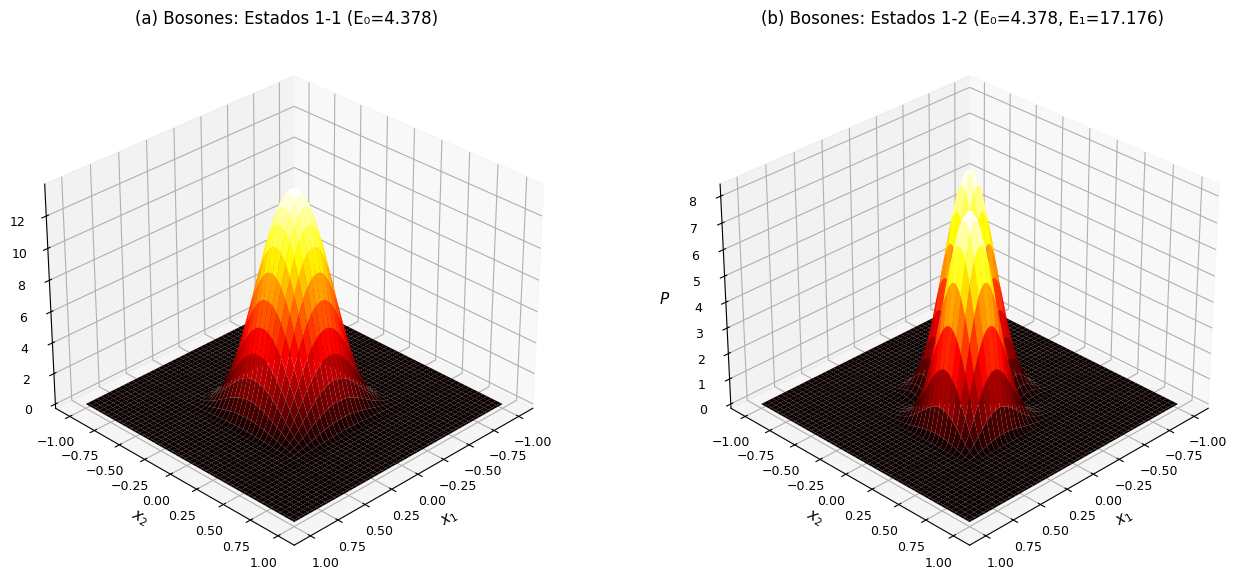

✓ Figura 2 guardada


In [85]:
# Grid para 2 partículas
x1_2d = np.linspace(-a - 0.5, a + 0.5, 100)
x2_2d = np.linspace(-a - 0.5, a + 0.5, 100)
X1, X2 = np.meshgrid(x1_2d, x2_2d)

print("Calculando probabilidades conjuntas para bosones...")

# Casos: (n1=1, n2=1) y (n1=1, n2=2) en índices [0, 0] y [0, 1]
Z1 = P2_bosons_finite(0, 0, X1, X2, eigenfunctions)
Z2 = P2_bosons_finite(0, 1, X1, X2, eigenfunctions)

fig = plt.figure(figsize=(14, 6))

# Subplot 1: (0,0)
ax = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax.plot_surface(X1, X2, Z1, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax.set_xlabel('$x_1$', fontsize=11)
ax.set_ylabel('$x_2$', fontsize=11)
ax.set_zlabel('$P$', fontsize=11)
ax.set_title(f'(a) Bosones: Estados 1-1 (E₀={eigenvalues[0]:.3f})', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

# Subplot 2: (0,1)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Z2, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.set_zlabel('$P$', fontsize=11)
ax2.set_title(f'(b) Bosones: Estados 1-2 (E₀={eigenvalues[0]:.3f}, E₁={eigenvalues[1]:.3f})', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('figures/finite_well_fig2_bosons.png', dpi=150)
plt.show()
print("✓ Figura 2 guardada")

## 10. FIGURA 3: Fermiones (2 Partículas)

Calculando probabilidades conjuntas para fermiones...


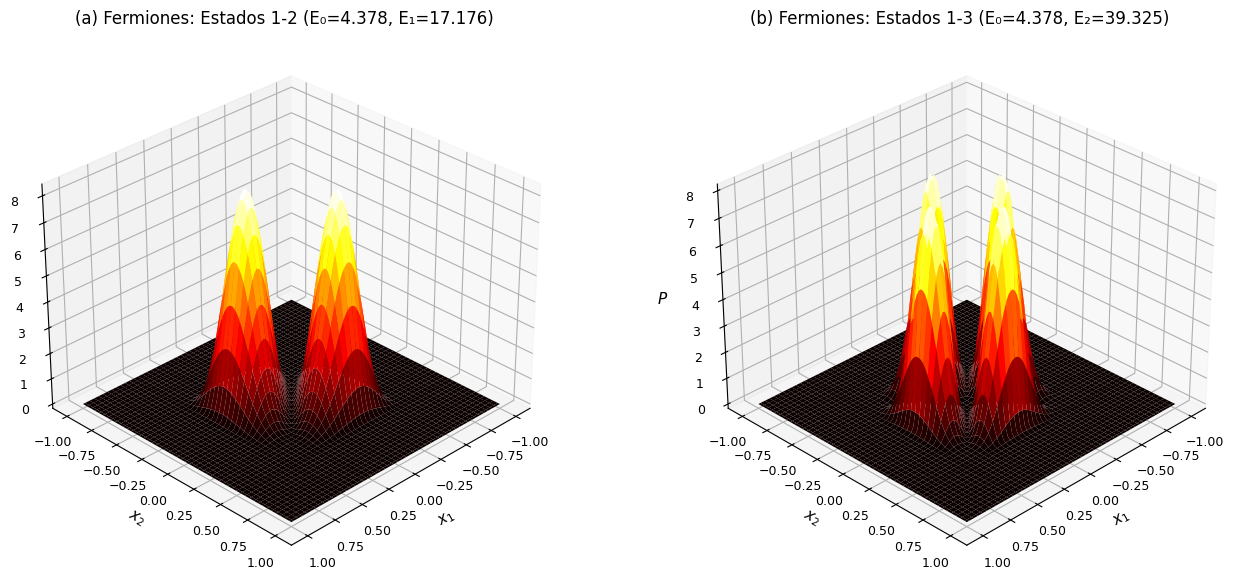

✓ Figura 3 guardada


In [86]:
print("Calculando probabilidades conjuntas para fermiones...")

# Casos: (n1=1, n2=2) y (n1=1, n2=3) en índices [0, 1] y [0, 2]
Z1 = P2_fermions_finite(0, 1, X1, X2, eigenfunctions)
Z2 = P2_fermions_finite(0, 2, X1, X2, eigenfunctions)

fig = plt.figure(figsize=(14, 6))

# Subplot 1: (0,1)
ax = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax.plot_surface(X1, X2, Z1, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax.set_xlabel('$x_1$', fontsize=11)
ax.set_ylabel('$x_2$', fontsize=11)
ax.set_zlabel('$P$', fontsize=11)
ax.set_title(f'(a) Fermiones: Estados 1-2 (E₀={eigenvalues[0]:.3f}, E₁={eigenvalues[1]:.3f})', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

# Subplot 2: (0,2)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Z2, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.set_zlabel('$P$', fontsize=11)
ax2.set_title(f'(b) Fermiones: Estados 1-3 (E₀={eigenvalues[0]:.3f}, E₂={eigenvalues[2]:.3f})', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('figures/finite_well_fig3_fermions.png', dpi=150)
plt.show()
print("✓ Figura 3 guardada")

## 11. FIGURA 4: Densidad Térmica para 2 Partículas

Funciones de termalización para 2 partículas definidas.

Calculando densidades térmicas para 2 partículas a T=10...
✓ Densidades calculadas


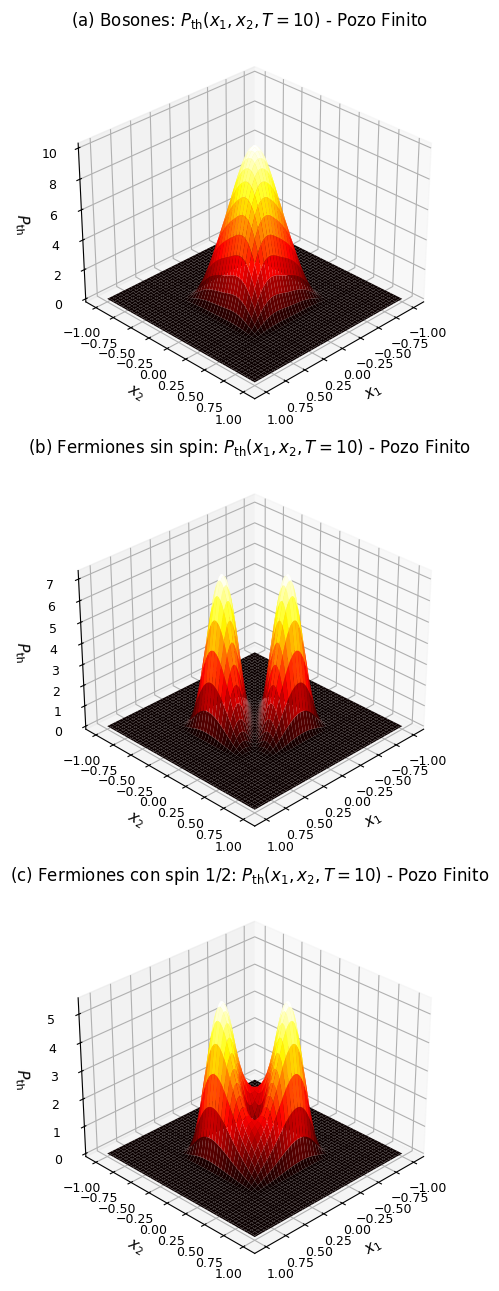

✓ Figura 4 guardada


In [87]:
def Pth_two_bosons_finite(X1, X2, T, eigenvalues, eigenfunctions, x_grid):
    """
    Densidad térmica para 2 bosones en pozo finito.
    """
    Z = np.zeros_like(X1)
    den = 0.0
    
    for i1 in range(len(eigenvalues)):
        for i2 in range(i1, len(eigenvalues)):  # i2 >= i1 para bosones
            # Peso de Boltzmann
            w = np.exp(-(eigenvalues[i1] + eigenvalues[i2]) / T)
            
            # Probabilidad conjunta
            P = P2_bosons_finite(i1, i2, X1, X2, eigenfunctions)
            Z += w * P
            den += w
    
    return Z / den


def Pth_two_fermions_finite(X1, X2, T, eigenvalues, eigenfunctions, x_grid):
    """
    Densidad térmica para 2 fermiones sin spin en pozo finito.
    """
    Z = np.zeros_like(X1)
    den = 0.0
    
    for i1 in range(len(eigenvalues)):
        for i2 in range(i1 + 1, len(eigenvalues)):  # i2 > i1 para fermiones
            # Peso de Boltzmann
            w = np.exp(-(eigenvalues[i1] + eigenvalues[i2]) / T)
            
            # Probabilidad conjunta
            P = P2_fermions_finite(i1, i2, X1, X2, eigenfunctions)
            Z += w * P
            den += w
    
    return Z / den


def Pth_two_spin_finite(X1, X2, T, eigenvalues, eigenfunctions, x_grid):
    """
    Densidad térmica para 2 fermiones con spin 1/2 en pozo finito.
    P = (1/4)*P_bosones + (3/4)*P_fermiones
    """
    # Densidades para bosones y fermiones
    Pb = np.zeros_like(X1)
    Pf = np.zeros_like(X1)
    den = 0.0
    
    for i1 in range(len(eigenvalues)):
        for i2 in range(i1 + 1, len(eigenvalues)):
            w = np.exp(-(eigenvalues[i1] + eigenvalues[i2]) / T)
            
            # Bosones (sin restricción)
            Pb += w * P2_bosons_finite(i1, i2, X1, X2, eigenfunctions)
            # Fermiones (antisimétrica)
            Pf += w * P2_fermions_finite(i1, i2, X1, X2, eigenfunctions)
            
            den += w
    
    # Combinar
    P_spin = (0.25 * Pb + 0.75 * Pf) / den
    
    return P_spin


print("Funciones de termalización para 2 partículas definidas.")

# Calcular para T = 10
print("\nCalculando densidades térmicas para 2 partículas a T=10...")
T = 10

Zb = Pth_two_bosons_finite(X1, X2, T, eigenvalues, eigenfunctions, x)
Zf = Pth_two_fermions_finite(X1, X2, T, eigenvalues, eigenfunctions, x)
Zs = Pth_two_spin_finite(X1, X2, T, eigenvalues, eigenfunctions, x)

print("✓ Densidades calculadas")

# Graficar
fig = plt.figure(figsize=(16, 13))

# Bosones
ax = fig.add_subplot(3, 1, 1, projection='3d')
surf = ax.plot_surface(X1, X2, Zb, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax.set_xlabel('$x_1$', fontsize=11)
ax.set_ylabel('$x_2$', fontsize=11)
ax.set_zlabel('$P_{\\rm th}$', fontsize=11)
ax.set_title(f'(a) Bosones: $P_{{\\rm th}}(x_1,x_2,T={T})$ - Pozo Finito', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

# Fermiones sin spin
ax2 = fig.add_subplot(3, 1, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Zf, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.set_zlabel('$P_{\\rm th}$', fontsize=11)
ax2.set_title(f'(b) Fermiones sin spin: $P_{{\\rm th}}(x_1,x_2,T={T})$ - Pozo Finito', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)

# Fermiones con spin
ax3 = fig.add_subplot(3, 1, 3, projection='3d')
surf3 = ax3.plot_surface(X1, X2, Zs, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax3.set_xlabel('$x_1$', fontsize=11)
ax3.set_ylabel('$x_2$', fontsize=11)
ax3.set_zlabel('$P_{\\rm th}$', fontsize=11)
ax3.set_title(f'(c) Fermiones con spin 1/2: $P_{{\\rm th}}(x_1,x_2,T={T})$ - Pozo Finito', fontsize=12, pad=10)
ax3.view_init(elev=30, azim=45)
ax3.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('figures/finite_well_fig4_thermal_2p.png', dpi=150)
plt.show()
print("✓ Figura 4 guardada")

## 12. FIGURA 5: Fermiones con Spin (Casos Específicos)

Calculando casos específicos de fermiones con spin...


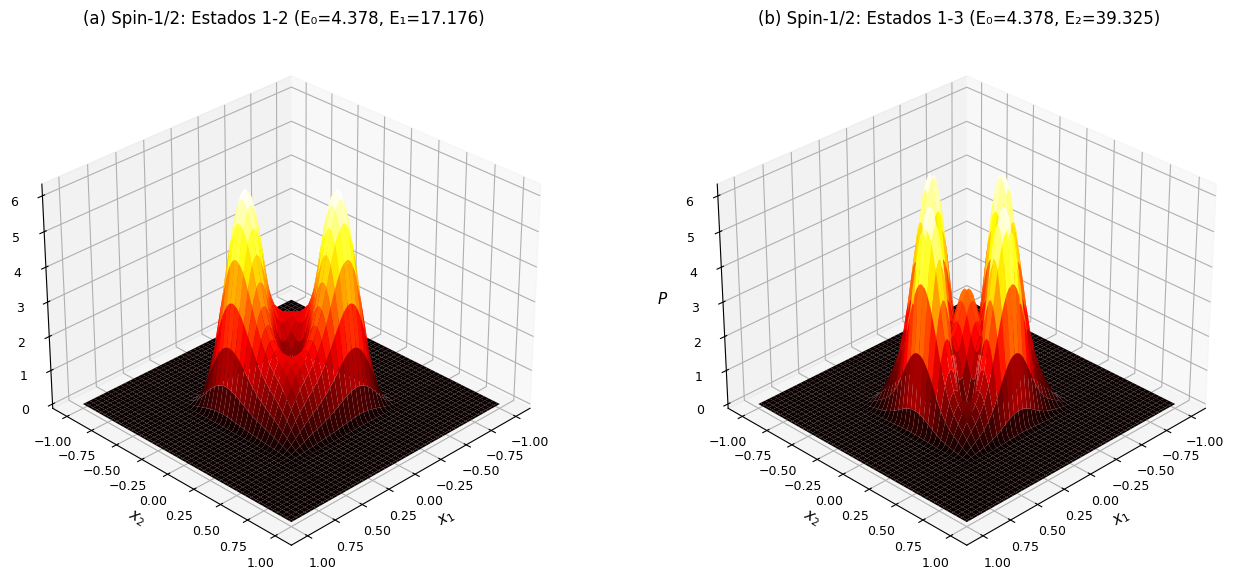

✓ Figura 5 guardada


In [88]:
def P2_spin_finite(i1, i2, x1, x2, eigenfunctions):
    """
    Probabilidad para fermiones con spin 1/2: P = (1/4)*P_b + (3/4)*P_f
    """
    Pb = P2_bosons_finite(i1, i2, x1, x2, eigenfunctions)
    Pf = P2_fermions_finite(i1, i2, x1, x2, eigenfunctions)
    return 0.25 * Pb + 0.75 * Pf


print("Calculando casos específicos de fermiones con spin...")

# Casos: (0,1) y (0,2)
Z1 = P2_spin_finite(0, 1, X1, X2, eigenfunctions)
Z2 = P2_spin_finite(0, 2, X1, X2, eigenfunctions)

fig = plt.figure(figsize=(14, 6))

# Subplot 1: (0,1)
ax = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax.plot_surface(X1, X2, Z1, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax.set_xlabel('$x_1$', fontsize=11)
ax.set_ylabel('$x_2$', fontsize=11)
ax.set_zlabel('$P$', fontsize=11)
ax.set_title(f'(a) Spin-1/2: Estados 1-2 (E₀={eigenvalues[0]:.3f}, E₁={eigenvalues[1]:.3f})', fontsize=12, pad=10)
ax.view_init(elev=30, azim=45)
ax.tick_params(labelsize=9)

# Subplot 2: (0,2)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X1, X2, Z2, cmap='hot', linewidth=0, antialiased=True, rstride=2, cstride=2)
ax2.set_xlabel('$x_1$', fontsize=11)
ax2.set_ylabel('$x_2$', fontsize=11)
ax2.set_zlabel('$P$', fontsize=11)
ax2.set_title(f'(b) Spin-1/2: Estados 1-3 (E₀={eigenvalues[0]:.3f}, E₂={eigenvalues[2]:.3f})', fontsize=12, pad=10)
ax2.view_init(elev=30, azim=45)
ax2.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('figures/finite_well_fig5_spin.png', dpi=150)
plt.show()
print("✓ Figura 5 guardada")

## 13. Resumen de Figuras Generadas

In [89]:
print("\n" + "="*70)
print("REPLICACIÓN COMPLETADA - POZO FINITO")
print("="*70)
print(f"\nParámetros del sistema:")
print(f"  Semi-ancho: a = {a:.4f}")
print(f"  Profundidad: V₀ = {V0:.1f}")
print(f"  Autovalores encontrados: {len(eigenvalues)}")
print(f"\nFiguras generadas:")
print(f"  ✓ Figura 1a: Densidad térmica P_th(x,T) para 1 partícula")
print(f"  ✓ Figura 1b: Ancho de capa límite d(T)")
print(f"  ✓ Figura 2: Probabilidad conjunta bosones (2 partículas)")
print(f"  ✓ Figura 3: Probabilidad conjunta fermiones (2 partículas)")
print(f"  ✓ Figura 4: Densidad térmica para 2 partículas (bosones, fermiones, spin-1/2)")
print(f"  ✓ Figura 5: Fermiones con spin 1/2 (casos específicos)")
print(f"\nArchivos guardados en: figures/")
print("="*70)


REPLICACIÓN COMPLETADA - POZO FINITO

Parámetros del sistema:
  Semi-ancho: a = 0.5000
  Profundidad: V₀ = 400.0
  Autovalores encontrados: 10

Figuras generadas:
  ✓ Figura 1a: Densidad térmica P_th(x,T) para 1 partícula
  ✓ Figura 1b: Ancho de capa límite d(T)
  ✓ Figura 2: Probabilidad conjunta bosones (2 partículas)
  ✓ Figura 3: Probabilidad conjunta fermiones (2 partículas)
  ✓ Figura 4: Densidad térmica para 2 partículas (bosones, fermiones, spin-1/2)
  ✓ Figura 5: Fermiones con spin 1/2 (casos específicos)

Archivos guardados en: figures/
